# Emotions Binary Classification Pipeline (Love Detection)

This notebook implements an **active learning pipeline** for binary emotion classification, following the same **LTS (Learning Through Sampling) structure** used in the 20 Newsgroups workflow:

## Pipeline Flow
1. **Configuration**: Set target emotion and paths
2. **Data Preparation**: Prepare binary classification dataset (target=1, others=0)
3. **Module Verification**: Ensure all required pipeline components are available
4. **Active Learning Loop**: Cluster → Sample → Pseudo-label → Fine-tune → Evaluate
5. **Final Evaluation**: Report metrics on held-out test set

## Task Definition
- **Label 1**: Target emotion = `love` (or configurable)
- **Label 0**: All other emotions
- **Objective**: Train a binary classifier using active learning with Thompson sampling

In [1]:
## Step 1: Environment Setup (Colab)

## Step 1: Environment Setup (Colab)

In [2]:
import os
import sys

REPO_URL = "https://github.com/ShenyaoZhang/DS-GA-3001-Data-Engineering-Project.git"
BRANCH = "emotions-rec-sentiments"

DRIVE_ROOT = "/content/drive/MyDrive"
REPO_ROOT = os.path.join(DRIVE_ROOT, "DS-GA-3001-Data-Engineering-Project")
EXPERIMENT_ROOT = os.path.join(REPO_ROOT, "emotions_rec")

LTS_DIR = os.path.join(EXPERIMENT_ROOT, "LTS")
PROMPTS_DIR = os.path.join(EXPERIMENT_ROOT, "prompts")
DATA_PROCESSED_DIR = os.path.join(EXPERIMENT_ROOT, "data", "processed")

if not os.path.exists(REPO_ROOT):
    !git clone -b {BRANCH} {REPO_URL} "{REPO_ROOT}"
else:
    %cd "{REPO_ROOT}"
    !git fetch origin
    !git checkout {BRANCH}
    !git pull

%cd "{EXPERIMENT_ROOT}"
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
if LTS_DIR not in sys.path:
    sys.path.insert(0, LTS_DIR)

print("Experiment root:", EXPERIMENT_ROOT)

import subprocess
from datetime import datetime

LOG_DIR = os.path.join(EXPERIMENT_ROOT, "logs")
os.makedirs(LOG_DIR, exist_ok=True)
print("Logs directory (persisted under your Drive repo):", LOG_DIR)


def run_logged(cmd, log_path, cwd=None, notebook_tail_lines=1200):
    """Append full subprocess output to ``log_path``; print only the last lines in the notebook (reduces Colab UI freezes)."""
    log_path = os.path.abspath(log_path)
    os.makedirs(os.path.dirname(log_path), exist_ok=True)
    stamp = datetime.now().isoformat(timespec="seconds")
    lines = []
    cmd_list = [str(x) for x in cmd]
    with open(log_path, "a", encoding="utf-8", errors="replace") as lf:
        lf.write(f"\n{'=' * 72}\n[{stamp}] $ {' '.join(cmd_list)}\n{'=' * 72}\n")
        lf.flush()
        try:
            p = subprocess.Popen(
                cmd_list,
                cwd=cwd,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                text=True,
                encoding="utf-8",
                errors="replace",
                bufsize=1,
            )
            assert p.stdout is not None
            for line in iter(p.stdout.readline, ""):
                lf.write(line)
                lf.flush()
                lines.append(line)
            p.stdout.close()
            rc = p.wait()
        except Exception as exc:
            lf.write(f"\n[run_logged] exception: {exc!r}\n")
            lf.flush()
            print(f"[run_logged] exception (see log): {exc!r}")
            raise

    if notebook_tail_lines is not None and notebook_tail_lines > 0:
        tail = lines[-notebook_tail_lines:]
        if len(lines) > notebook_tail_lines:
            print(f"\n... ({len(lines) - notebook_tail_lines} earlier lines only in log file)\n")
    else:
        tail = lines

    try:
        sys.stdout.write("".join(tail))
        sys.stdout.flush()
    except (BrokenPipeError, UnicodeEncodeError) as exc:
        print(f"[notebook stdout skipped: {exc!r}]")

    print(f"\n[exit {rc}] full log: {log_path}")
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd_list)
    return rc



Cloning into '/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project'...
remote: Enumerating objects: 984, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 984 (delta 74), reused 98 (delta 51), pack-reused 842 (from 1)
Receiving objects: 100% (984/984), 46.92 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (503/503), done.
/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
Experiment root: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
Logs directory (persisted under your Drive repo): /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs


## Step 2: Configuration & Paths

Set up repository paths, target emotion, and experiment directories.

In [12]:
from getpass import getpass
import os

token = getpass("Enter your HF token: ")
os.environ["HF_TOKEN"] = token
os.environ["HUGGINGFACE_HUB_TOKEN"] = token
print("HF token set.")


Enter your HF token: ··········
HF token set.


## Step 3: Authentication & Dependencies

Long installs stream to **`emotions_rec/logs/`** on your Drive (`pip_*.log`, etc.). The notebook prints only the **tail** of each subprocess so huge logs do not freeze Colab; open the `.log` files for full output.


In [13]:
%cd "{EXPERIMENT_ROOT}"
run_logged(
    ["python", "-m", "pip", "install", "-r", os.path.join(REPO_ROOT, "requirements.txt")],
    os.path.join(LOG_DIR, "pip_requirements.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=500,
)
run_logged(
    ["python", "-m", "pip", "install", "datasets"],
    os.path.join(LOG_DIR, "pip_datasets.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=500,
)


/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.4 MB/s eta 0:00:00

[exit 0] full log: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/pip_requirements.log

[exit 0] full log: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/pip_datasets.log


0

### Install Requirements

In [14]:
TARGET_LABEL = "love"

%cd "{EXPERIMENT_ROOT}"
run_logged(
    ["python", "-u", "scripts/prepare_emotions_binary.py", "--label", TARGET_LABEL],
    os.path.join(LOG_DIR, "prepare_emotions_binary.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=800,
)

TRAIN_FILE = f"data/processed/emotions_{TARGET_LABEL}_smoke_train"
VAL_FILE = f"data/processed/emotions_{TARGET_LABEL}_smoke_validation.csv"
TEST_FILE = f"data/processed/emotions_{TARGET_LABEL}_test.csv"
# Full validation for threshold tuning / reporting (distribution closer to benchmark test than smoke val)
FULL_VAL_TUNING_PATH = f"data/processed/emotions_{TARGET_LABEL}_validation.csv"

print("Train:", TRAIN_FILE)
print("Val:  ", VAL_FILE)
print("Test: ", TEST_FILE)


/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec

Generating train split: 100%|██████████| 16000/16000 [00:00<00:00, 406838.74 examples/s]

Generating validation split: 100%|██████████| 2000/2000 [00:00<00:00, 550939.71 examples/s]

Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 668308.48 examples/s]
[prepare_emotions_binary] wrote data/processed/emotions_love_train.csv (16000 rows)
[prepare_emotions_binary] wrote data/processed/emotions_love_validation.csv (2000 rows)
[prepare_emotions_binary] wrote data/processed/emotions_love_test.csv (2000 rows)
[prepare_emotions_binary] wrote data/processed/emotions_love_smoke_train.csv (1200 rows)
[prepare_emotions_binary] wrote data/processed/emotions_love_smoke_validation.csv (300 rows)
[prepare_emotions_binary] target='love' positive_id=2
[prepare_emotions_binary] train multiclass labels: {0: 4666, 1: 5362, 2: 1304, 3: 2159, 4: 1937, 5: 572}
[prepare_emotions_binary] val multiclass labels: {0: 550, 1: 70

## Step 4: Data Preparation (Binary Classification Task)

Configure target emotion and prepare binary dataset (love=1, others=0).

In [15]:
import pandas as pd

train_df = pd.read_csv(TRAIN_FILE + ".csv")
val_df = pd.read_csv(VAL_FILE)
test_df = pd.read_csv(TEST_FILE)

print("train distribution:", train_df["label"].value_counts().to_dict())
print("val distribution:", val_df["label"].value_counts().to_dict())
print("test distribution:", test_df["label"].value_counts().to_dict())


train distribution: {2: 400, 1: 299, 0: 238, 3: 119, 4: 115, 5: 29}
val distribution: {2: 100, 1: 88, 0: 55, 3: 25, 4: 19, 5: 13}
test distribution: {1: 695, 0: 581, 3: 275, 4: 224, 2: 159, 5: 66}


### Verify Data Splits & Distributions

In [16]:
EXPECTED = [
    "preprocessing.py",
    "LDA.py",
    "labeling.py",
    "random_sampling.py",
    "thompson_sampling.py",
    "fine_tune.py",
    "main_cluster_emotion_binary.py",
    "eval_emotion_binary.py",
]

missing = []
for name in EXPECTED:
    path = os.path.join(LTS_DIR, name)
    ok = os.path.exists(path)
    print(f"{name}: {'FOUND' if ok else 'MISSING'}")
    if not ok:
        missing.append(name)

script_ok = os.path.exists(os.path.join(EXPERIMENT_ROOT, "scripts", "prepare_emotions_binary.py"))
print("scripts/prepare_emotions_binary.py:", "FOUND" if script_ok else "MISSING")
if not script_ok:
    missing.append("scripts/prepare_emotions_binary.py")

if missing:
    raise FileNotFoundError(f"Missing: {missing}")


preprocessing.py: FOUND
LDA.py: FOUND
labeling.py: FOUND
random_sampling.py: FOUND
thompson_sampling.py: FOUND
fine_tune.py: FOUND
main_cluster_emotion_binary.py: FOUND
eval_emotion_binary.py: FOUND
scripts/prepare_emotions_binary.py: FOUND


## Step 5: Module & Pipeline Verification

Verify all required components (preprocessing, LDA, labeling, sampling, fine-tuning) are present and compile correctly.

In [17]:
targets = [os.path.join(LTS_DIR, f) for f in EXPECTED]
run_logged(
    ["python", "-m", "py_compile", *targets],
    os.path.join(LOG_DIR, "py_compile.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=None,
)
print("py_compile finished (see log above and file).")



[exit 0] full log: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/py_compile.log
py_compile finished (see log above and file).


### Compile Python Modules

In [18]:
# Full training log: emotions_rec/logs/active_learning_train.log (tail printed below to avoid Colab freezing).
os.chdir(EXPERIMENT_ROOT)
train_cmd = [
    "python",
    "-u",
    "LTS/main_cluster_emotion_binary.py",
    "-sample_size",
    "400",
    "-filename",
    TRAIN_FILE,
    "-val_path",
    VAL_FILE,
    "-balance",
    "False",
    "-sampling",
    "thompson",
    "-filter_label",
    "True",
    "-model_finetune",
    "bert-base-uncased",
    "-labeling",
    "qwen",
    "-model",
    "text",
    "-baseline",
    "0.10",
    "-metric",
    "f1_pos",
    "-cluster_size",
    "8",
    "-positive_label",
    TARGET_LABEL,
    "-hf_model_id",
    "Qwen/Qwen2.5-3B-Instruct",
    "-max_iterations",
    "3",
    "-num_train_epochs",
    "2",
    "-max_length",
    "128",
    "-batch_size",
    "16",
    "-confidence_threshold",
    "0.40",
]
print("val_path will be:", VAL_FILE)
run_logged(
    train_cmd,
    os.path.join(LOG_DIR, "active_learning_train.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=1500,
)


val_path will be: data/processed/emotions_love_smoke_validation.csv

... (2318 earlier lines only in log file)

Loading weights: 100%|██████████| 434/434 [00:23<00:00, 18.73it/s, Materializing param=model.norm.weight]
Qwen model loaded
df for inference created

Map: 100%|██████████| 171/171 [00:00<00:00, 3617.18 examples/s]

100%|██████████| 11/11 [00:01<00:00,  9.74it/s]
Confidence filter: kept 171/171
Pseudo-label distribution: {0: 154, 1: 17}
Previous f1_pos baseline: 0.100000

Map: 100%|██████████| 171/171 [00:00<00:00, 6304.90 examples/s]

Map: 100%|██████████| 300/300 [00:00<00:00, 6913.84 examples/s]
Dynamic class weights: [0.19883039593696594, 1.8011696338653564]

 45%|████▌     | 10/22 [00:03<00:04,  2.98it/s]
                                               
{'loss': '0.6614', 'grad_norm': '5.987', 'learning_rate': '1.182e-05', 'epoch': '0.9091'}

 50%|█████     | 11/22 [00:03<00:03,  3.26it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

 11%|█         | 2/19 [00:00<00:00, 17.48it

0

### Optional: random sampling baseline (fair vs Thompson)

Same **`TRAIN_FILE`**, **`VAL_FILE`**, and **`TEST_FILE`** as above (same validation set during training; same held-out test when you eval). Uses **`-run_tag random`** so results/checkpoints/sampler state do not overwrite Thompson.

Recommended order: run Thompson **first** so LDA exists; then set **`RUN_RANDOM_COMPARE = True`** in the next cell and run it.


In [27]:
RUN_RANDOM_COMPARE = True  # set True to train random sampler baseline after Thompson

if RUN_RANDOM_COMPARE:
    os.chdir(EXPERIMENT_ROOT)
    train_random_cmd = [
        "python",
        "-u",
        "LTS/main_cluster_emotion_binary.py",
        "-sample_size",
        "400",
        "-filename",
        TRAIN_FILE,
        "-val_path",
        VAL_FILE,
        "-balance",
        "False",
        "-sampling",
        "random",
        "-run_tag",
        "random",
        "-filter_label",
        "True",
        "-model_finetune",
        "bert-base-uncased",
        "-labeling",
        "qwen",
        "-model",
        "text",
        "-baseline",
        "0.10",
        "-metric",
        "f1_pos",
        "-cluster_size",
        "8",
        "-positive_label",
        TARGET_LABEL,
        "-hf_model_id",
        "Qwen/Qwen2.5-3B-Instruct",
        "-max_iterations",
        "3",
        "-num_train_epochs",
        "2",
        "-max_length",
        "128",
        "-batch_size",
        "16",
        "-confidence_threshold",
        "0.40",
    ]
    run_logged(
        train_random_cmd,
        os.path.join(LOG_DIR, "active_learning_train_random.log"),
        cwd=EXPERIMENT_ROOT,
        notebook_tail_lines=1500,
    )
else:
    print("Skipping random baseline (set RUN_RANDOM_COMPARE = True).")



... (2570 earlier lines only in log file)


Map: 100%|██████████| 400/400 [00:00<00:00, 3776.30 examples/s]

Map: 100%|██████████| 300/300 [00:00<00:00, 6890.74 examples/s]
Dynamic class weights: [0.1849999874830246, 1.8149999380111694]

 20%|██        | 10/50 [00:03<00:13,  2.98it/s]
                                               
{'loss': '0.6788', 'grad_norm': '10.36', 'learning_rate': '1.64e-05', 'epoch': '0.4'}

 40%|████      | 20/50 [00:06<00:10,  2.95it/s]
                                               
{'loss': '0.6775', 'grad_norm': '3.605', 'learning_rate': '1.24e-05', 'epoch': '0.8'}

 50%|█████     | 25/50 [00:08<00:08,  2.94it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

 11%|█         | 2/19 [00:00<00:01, 16.47it/s]

 21%|██        | 4/19 [00:00<00:01, 10.43it/s]

 32%|███▏      | 6/19 [00:00<00:01,  9.36it/s]

 42%|████▏     | 8/19 [00:00<00:01,  8.96it/s]

 47%|████▋     | 9/19 [00:00<00:01,  8.86it/s]

 53%|█████▎    | 10/19 [00:01<00:01,  8.78it/s]

 58%|█████▊    | 

## Step 6: Active Learning Training Pipeline

Run the main LTS loop: **Cluster → Sample → Pseudo-label → Fine-tune → Evaluate**

This implements active learning with Thompson sampling to iteratively improve the binary love emotion classifier.

Full training output is appended to **`logs/active_learning_train.log`** on Drive; the code cell prints only the **last ~1500 lines** here so Colab stays responsive.


## Step 6b: Per-cluster validation metrics

After training, inspect **validation metrics by LDA cluster** (`validation_per_cluster` in the JSON). Each row reflects performance on validation examples assigned to that topic id.

**Requirements:** `{TRAIN_FILE}_lda.pkl` must exist (created when LDA is first built). If you only have `{TRAIN_FILE}_lda.csv`, delete the CSV once and rerun training so the pickle is written.

Results file: `{TRAIN_FILE}_binary_{TARGET_LABEL}_model_results.json`.

Optional random baseline (same splits): `{TRAIN_FILE}_binary_{TARGET_LABEL}_random_model_results.json` — reuse the Step 6b/6c cells by pointing `MODEL_RESULTS_PATH` at that file.

**Step 6c** (below) saves metric plots to `logs/figures/`.


In [28]:
from pathlib import Path
figs = sorted((Path(EXPERIMENT_ROOT) / "logs" / "figures").glob("*.png"))
print("Found figs:", len(figs))
for p in figs:
    print(p)

Found figs: 1
/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/figures/active_learning_metrics.png


In [29]:
import json
from pathlib import Path

import pandas as pd

%cd "{EXPERIMENT_ROOT}"

MODEL_RESULTS_PATH = Path(EXPERIMENT_ROOT) / f"{TRAIN_FILE}_binary_{TARGET_LABEL}_model_results.json"
LDA_PKL = Path(EXPERIMENT_ROOT) / f"{TRAIN_FILE}_lda.pkl"

print("Model results:", MODEL_RESULTS_PATH)
print("LDA pickle:", LDA_PKL, "(exists)" if LDA_PKL.is_file() else "(missing — per-cluster block may be absent in JSON)")

if not MODEL_RESULTS_PATH.is_file():
    raise FileNotFoundError(f"Run Step 6 training first. Expected: {MODEL_RESULTS_PATH}")

with open(MODEL_RESULTS_PATH, encoding="utf-8") as f:
    history = json.load(f)

rows = []
for bandit_key, rounds in history.items():
    for round_idx, rec in enumerate(rounds):
        vpc = rec.get("validation_per_cluster")
        base = {
            "bandit": bandit_key,
            "round": round_idx + 1,
            "eval_f1_pos": rec.get("eval_f1_pos"),
            "eval_accuracy": rec.get("eval_accuracy"),
        }
        if not vpc or not isinstance(vpc, dict):
            rows.append({**base, "lda_cluster": None, "note": "no validation_per_cluster — rebuild LDA with .pkl"})
            continue
        if vpc.get("error"):
            rows.append({**base, "lda_cluster": None, "note": f"error: {vpc.get('error')}"})
            continue
        for cid, stats in vpc.items():
            row = {**base, "lda_cluster": cid}
            if isinstance(stats, dict):
                for k, v in stats.items():
                    row[f"val_{k}"] = v
            rows.append(row)

df = pd.DataFrame(rows)
if df.empty:
    print("No rows to display.")
else:
    sort_cols = [c for c in ["bandit", "round", "lda_cluster"] if c in df.columns]
    display(df.sort_values(sort_cols, na_position="last"))


/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
Model results: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/data/processed/emotions_love_smoke_train_binary_love_model_results.json
LDA pickle: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/data/processed/emotions_love_smoke_train_lda.pkl (exists)


,bandit,round,eval_f1_pos,eval_accuracy,lda_cluster,val_n,val_accuracy,val_precision_weighted,val_recall_weighted,val_f1_weighted,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_pos,val_recall_pos,val_f1_pos
8,0,1,0.000000,0.666667,0,52,0.615385,0.378698,0.615385,0.468864,0.307692,0.500000,0.380952,0.000000,0.000000,0.000000
9,0,1,0.000000,0.666667,1,12,0.833333,0.694444,0.833333,0.757576,0.416667,0.500000,0.454545,0.000000,0.000000,0.000000
10,0,1,0.000000,0.666667,2,19,0.684211,0.468144,0.684211,0.555921,0.342105,0.500000,0.406250,0.000000,0.000000,0.000000
11,0,1,0.000000,0.666667,3,24,0.708333,0.501736,0.708333,0.587398,0.354167,0.500000,0.414634,0.000000,0.000000,0.000000
12,0,1,0.000000,0.666667,4,44,0.704545,0.496384,0.704545,0.582424,0.352273,0.500000,0.413333,0.000000,0.000000,0.000000
13,0,1,0.000000,0.666667,5,62,0.612903,0.375650,0.612903,0.465806,0.306452,0.500000,0.380000,0.000000,0.000000,0.000000
14,0,1,0.000000,0.666667,6,48,0.687500,0.472656,0.687500,0.560185,0.343750,0.500000,0.407407,0.000000,0.000000,0.000000
15,0,1,0.000000,0.666667,7,39,0.666667,0.444444,0.666667,0.533333,0.333333,0.500000,0.400000,0.000000,0.000000,0.000000
16,2,1,0.517413,0.676667,0,52,0.692308,0.684829,0.692308,0.684263,0.673611,0.656250,0.660131,0.625000,0.500000,0.555556
17,2,1,0.517413,0.676667,1,12,0.666667,0.770833,0.666667,0.703704,0.562500,0.600000,0.555556,0.250000,0.500000,0.333333


## Step 6c: Plots (validation metrics)

Loads `{TRAIN_FILE}_binary_{TARGET_LABEL}_model_results.json`, saves figures under **`logs/figures/`** on Drive, and shows them inline (small PNGs to avoid Colab stalls).


/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
Saved: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/figures/active_learning_metrics.png


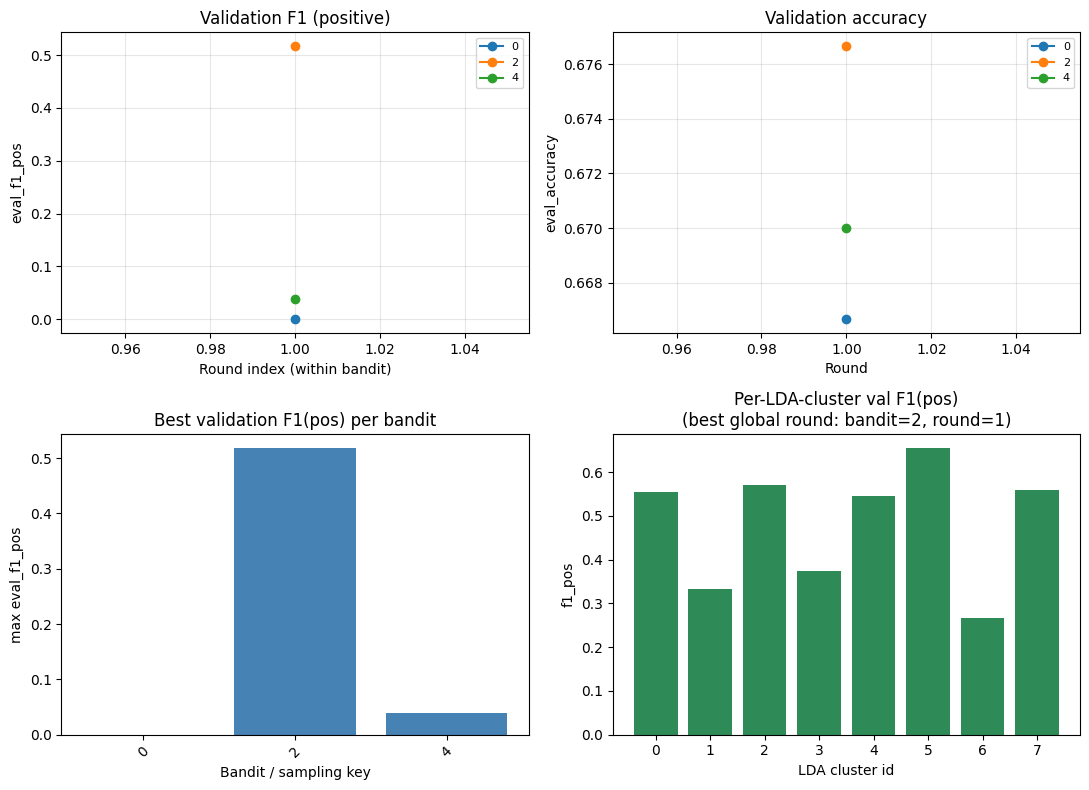

In [30]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%cd "{EXPERIMENT_ROOT}"

METRIC_KEY = "eval_f1_pos"  # matches default -metric f1_pos in training cell


def _to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan


MODEL_RESULTS_PATH = Path(EXPERIMENT_ROOT) / f"{TRAIN_FILE}_binary_{TARGET_LABEL}_model_results.json"
FIG_DIR = Path(EXPERIMENT_ROOT) / "logs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not MODEL_RESULTS_PATH.is_file():
    print("No results file yet — run Step 6 training first:", MODEL_RESULTS_PATH)
else:
    with open(MODEL_RESULTS_PATH, encoding="utf-8") as f:
        history = json.load(f)

    rows = []
    for bandit_key, rounds in history.items():
        if not isinstance(rounds, list):
            continue
        for i, rec in enumerate(rounds):
            if not isinstance(rec, dict):
                continue
            rows.append(
                {
                    "bandit": str(bandit_key),
                    "round": i + 1,
                    "eval_f1_pos": _to_float(rec.get("eval_f1_pos")),
                    "eval_accuracy": _to_float(rec.get("eval_accuracy")),
                    "eval_f1_macro": _to_float(rec.get("eval_f1_macro")),
                    "eval_loss": _to_float(rec.get("eval_loss")),
                }
            )

    metrics_df = pd.DataFrame(rows)
    if metrics_df.empty:
        print("JSON loaded but no metric rows parsed.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(11, 8))

        ax = axes[0, 0]
        for b, g in metrics_df.groupby("bandit"):
            g = g.sort_values("round")
            ax.plot(g["round"], g["eval_f1_pos"], marker="o", label=str(b))
        ax.set_title("Validation F1 (positive)")
        ax.set_xlabel("Round index (within bandit)")
        ax.set_ylabel(METRIC_KEY)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

        ax = axes[0, 1]
        for b, g in metrics_df.groupby("bandit"):
            g = g.sort_values("round")
            ax.plot(g["round"], g["eval_accuracy"], marker="o", label=str(b))
        ax.set_title("Validation accuracy")
        ax.set_xlabel("Round")
        ax.set_ylabel("eval_accuracy")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")

        ax = axes[1, 0]
        best_per_bandit = metrics_df.groupby("bandit", as_index=False)["eval_f1_pos"].max()
        ax.bar(best_per_bandit["bandit"].astype(str), best_per_bandit["eval_f1_pos"], color="steelblue")
        ax.set_title("Best validation F1(pos) per bandit")
        ax.set_xlabel("Bandit / sampling key")
        ax.set_ylabel("max eval_f1_pos")
        ax.tick_params(axis="x", rotation=45)

        ax = axes[1, 1]
        best_idx = metrics_df["eval_f1_pos"].idxmax()
        bkey = str(metrics_df.loc[best_idx, "bandit"])
        ridx = int(metrics_df.loc[best_idx, "round"]) - 1
        rounds_list = history.get(bkey)
        if rounds_list is None:
            for k in history:
                if str(k) == bkey:
                    rounds_list = history[k]
                    break
        vpc = None
        if isinstance(rounds_list, list) and 0 <= ridx < len(rounds_list):
            rec_pick = rounds_list[ridx]
            if isinstance(rec_pick, dict):
                vpc = rec_pick.get("validation_per_cluster")
        clusters, fps = [], []
        if isinstance(vpc, dict) and not vpc.get("error"):
            for cid, st in sorted(vpc.items(), key=lambda x: str(x[0])):
                if not isinstance(st, dict) or st.get("f1_pos") is None:
                    continue
                clusters.append(str(cid))
                fps.append(_to_float(st["f1_pos"]))
        if not clusters:
            ax.text(
                0.5,
                0.5,
                "No per-cluster F1\n(use *_lda.pkl + multiclass CSVs)",
                ha="center",
                va="center",
            )
            ax.axis("off")
        else:
            ax.bar(clusters, fps, color="seagreen")
            ax.set_title(f'Per-LDA-cluster val F1(pos)\n(best global round: bandit={bkey}, round={ridx + 1})')
            ax.set_xlabel("LDA cluster id")
            ax.set_ylabel("f1_pos")

        plt.tight_layout()
        out_path = FIG_DIR / "active_learning_metrics.png"
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        print("Saved:", out_path)
        plt.show()


## Step 7: Final Evaluation on Test Set

Use **Step 6b** to compare validation performance **by LDA cluster**; here we score **held-out test** examples.

Evaluate on the held-out test set. The Step 7 cell **auto-picks** the latest saved checkpoint folder that matches your emotion and **`EVAL_RUN_TAG`** (each round saves only if validation improves — there may be no `*_0_bandit_0`). Pin a folder with **`CHECKPOINT_DIR_OVERRIDE`** if needed.

After the optional random baseline, set **`EVAL_RUN_TAG = "random"`** (same **`TEST_FILE`**).

**Metrics reported:**
- Positive-class (love) precision, recall, F1
- Macro-averaged F1
- Accuracy
- Mean confidence score

In [31]:
%cd "{EXPERIMENT_ROOT}"
!ls -la models

/content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec
total 20
drwxr-xr-x  5 root root 4096 May  7 12:08 .
drwxr-xr-x 12 root root 4096 May  7 11:52 ..
drwxr-xr-x  2 root root 4096 May  7 11:27 binary_love_fine_tunned_2_bandit_2
drwxr-xr-x  2 root root 4096 May  7 12:03 binary_love_random_fine_tunned_1_bandit_random
drwxr-xr-x  2 root root 4096 May  7 12:08 binary_love_random_fine_tunned_2_bandit_random


In [32]:
# Folder must contain config.json. Training only saves when reward > 0, so *_0_bandit_0 may not exist.
# Same TEST_FILE every run; EVAL_RUN_TAG selects Thompson vs random checkpoint families.
import re

EVAL_RUN_TAG = ""  # "" = Thompson default; "random" = optional baseline cell above
_ckpt_infix = f"{EVAL_RUN_TAG}_" if EVAL_RUN_TAG else ""

# Set to a full path under EXPERIMENT_ROOT/models/... to pin one checkpoint; None = auto-pick latest saved.
CHECKPOINT_DIR_OVERRIDE = None

MODELS_DIR = os.path.join(EXPERIMENT_ROOT, "models")
_dir_pat = re.compile(
    rf"^binary_{re.escape(TARGET_LABEL)}_{re.escape(_ckpt_infix)}fine_tunned_(\d+)_bandit_(\d+)$"
)


def _resolve_checkpoint_dir():
    if CHECKPOINT_DIR_OVERRIDE:
        p = os.path.abspath(os.path.expanduser(str(CHECKPOINT_DIR_OVERRIDE)))
        if not os.path.isdir(p) or not os.path.isfile(os.path.join(p, "config.json")):
            raise FileNotFoundError(
                f"CHECKPOINT_DIR_OVERRIDE must be an existing folder with config.json: {p!r}"
            )
        return p
    if not os.path.isdir(MODELS_DIR):
        raise FileNotFoundError(f"No models directory: {MODELS_DIR}")
    found = []
    for name in os.listdir(MODELS_DIR):
        m = _dir_pat.match(name)
        if not m:
            continue
        path = os.path.join(MODELS_DIR, name)
        if os.path.isdir(path) and os.path.isfile(os.path.join(path, "config.json")):
            it, bd = int(m.group(1)), int(m.group(2))
            found.append((it, bd, os.path.getmtime(path), path))
    if not found:
        raise FileNotFoundError(
            f"No saved checkpoints matching binary_{TARGET_LABEL}_{_ckpt_infix}fine_tunned_*_bandit_* "
            f"with config.json under {MODELS_DIR}. Train until logs show 'Model improved and saved', "
            "or set CHECKPOINT_DIR_OVERRIDE to the path printed there."
        )
    found.sort(key=lambda t: (t[0], t[1], t[2]))
    _it, _bd, _mt, path = found[-1]
    print(f"Using checkpoint iter={_it} bandit={_bd} (latest by iteration, then mtime): {path}")
    return path


CHECKPOINT_DIR = _resolve_checkpoint_dir()

eval_cmd = [
    "python",
    "-u",
    "LTS/eval_emotion_binary.py",
    "-test_path",
    TEST_FILE,
    "-model_path",
    CHECKPOINT_DIR,
    "-target_emotion",
    TARGET_LABEL,
    "-base_model",
    "bert-base-uncased",
    "-max_length",
    "128",
]
run_logged(
    eval_cmd,
    os.path.join(LOG_DIR, "eval_test.log"),
    cwd=EXPERIMENT_ROOT,
    notebook_tail_lines=None,
)


Using checkpoint iter=2 bandit=2 (latest by iteration, then mtime): /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/models/binary_love_fine_tunned_2_bandit_2

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 603.64it/s, Materializing param=classifier.weight]

=== Binary evaluation (love vs rest) ===
              precision    recall  f1-score   support

       other       0.95      0.68      0.79      1841
        love       0.13      0.57      0.21       159

    accuracy                           0.67      2000
   macro avg       0.54      0.62      0.50      2000
weighted avg       0.88      0.67      0.74      2000

Accuracy:         0.6670
Precision (pos):  0.1321
Recall (pos):     0.5723
F1 (pos):         0.2146
F1 Macro:         0.5017
Mean confidence:  0.5161

[exit 0] full log: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/logs/eval_test.log


0

Thompson file: /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/data/processed/emotions_love_smoke_train_binary_love_model_results.json OK
Random file:   /content/drive/MyDrive/DS-GA-3001-Data-Engineering-Project/emotions_rec/data/processed/emotions_love_smoke_train_binary_love_random_model_results.json OK

=== Method Summary ===


,method,best_f1_pos,mean_f1_pos,best_accuracy,n_round_rows
0,random,0.411348,0.266612,0.723333,3
1,thompson,0.517413,0.185416,0.676667,3



=== Best Round Per Method ===


,method,bandit,round,eval_f1_pos,eval_accuracy,eval_f1_macro
5,random,random,3,0.411348,0.723333,0.615260
2,thompson,2,1,0.517413,0.676667,0.637153



Delta best F1_pos (thompson - random): +0.1061
Delta mean F1_pos (thompson - random): -0.0812


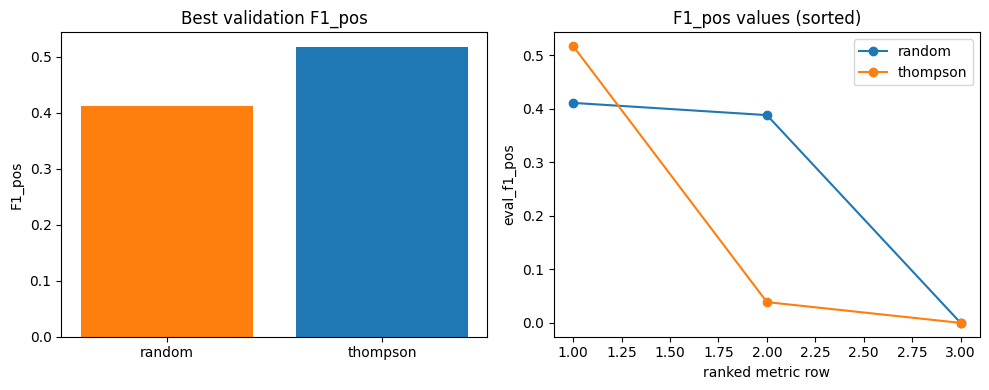


Interpretation: This run supports the LTS hypothesis (Thompson > random on best F1_pos).


In [33]:
# Step 6d: Thompson vs Random summary (same budget/splits)
# Purpose: quickly test whether adaptive sampling supports your project goal on Emotions.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses existing vars from your notebook:
# EXPERIMENT_ROOT, TRAIN_FILE, TARGET_LABEL

def _to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

def _load_history(path: Path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def _flatten_history(history, method_name):
    rows = []
    for bandit_key, rounds in history.items():
        if not isinstance(rounds, list):
            continue
        for i, rec in enumerate(rounds):
            if not isinstance(rec, dict):
                continue
            rows.append(
                {
                    "method": method_name,
                    "bandit": str(bandit_key),
                    "round": i + 1,
                    "eval_f1_pos": _to_float(rec.get("eval_f1_pos")),
                    "eval_accuracy": _to_float(rec.get("eval_accuracy")),
                    "eval_f1_macro": _to_float(rec.get("eval_f1_macro")),
                }
            )
    return pd.DataFrame(rows)

root = Path(EXPERIMENT_ROOT)
th_path = root / f"{TRAIN_FILE}_binary_{TARGET_LABEL}_model_results.json"
rd_path = root / f"{TRAIN_FILE}_binary_{TARGET_LABEL}_random_model_results.json"

print("Thompson file:", th_path, "OK" if th_path.is_file() else "MISSING")
print("Random file:  ", rd_path, "OK" if rd_path.is_file() else "MISSING")

if not th_path.is_file() or not rd_path.is_file():
    raise FileNotFoundError("Need BOTH Thompson and random *_model_results.json files to compare.")

th_df = _flatten_history(_load_history(th_path), "thompson")
rd_df = _flatten_history(_load_history(rd_path), "random")

if th_df.empty or rd_df.empty:
    raise ValueError("One of the results files has no parsed metric rows.")

all_df = pd.concat([th_df, rd_df], ignore_index=True)

# ---- Summary stats for report goal (minority-class triage) ----
summary = (
    all_df.groupby("method", as_index=False)
    .agg(
        best_f1_pos=("eval_f1_pos", "max"),
        mean_f1_pos=("eval_f1_pos", "mean"),
        best_accuracy=("eval_accuracy", "max"),
        n_round_rows=("eval_f1_pos", "count"),
    )
)

# optional: "best observed round" snapshot
best_rows = all_df.loc[all_df.groupby("method")["eval_f1_pos"].idxmax()].copy()
best_rows = best_rows[["method", "bandit", "round", "eval_f1_pos", "eval_accuracy", "eval_f1_macro"]]

print("\n=== Method Summary ===")
display(summary.sort_values("method"))

print("\n=== Best Round Per Method ===")
display(best_rows.sort_values("method"))

# delta (thompson - random)
s = summary.set_index("method")
delta_best = s.loc["thompson", "best_f1_pos"] - s.loc["random", "best_f1_pos"]
delta_mean = s.loc["thompson", "mean_f1_pos"] - s.loc["random", "mean_f1_pos"]
print(f"\nDelta best F1_pos (thompson - random): {delta_best:+.4f}")
print(f"Delta mean F1_pos (thompson - random): {delta_mean:+.4f}")

# ---- Small visualization ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# best F1_pos bar
plot_df = summary.sort_values("method")
axes[0].bar(plot_df["method"], plot_df["best_f1_pos"], color=["tab:orange", "tab:blue"])
axes[0].set_title("Best validation F1_pos")
axes[0].set_ylabel("F1_pos")

# distributions across all rows
for method, g in all_df.groupby("method"):
    axes[1].plot(np.arange(1, len(g) + 1), g["eval_f1_pos"].sort_values(ascending=False).values, marker="o", label=method)
axes[1].set_title("F1_pos values (sorted)")
axes[1].set_xlabel("ranked metric row")
axes[1].set_ylabel("eval_f1_pos")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quick interpretation helper
if delta_best > 0:
    print("\nInterpretation: This run supports the LTS hypothesis (Thompson > random on best F1_pos).")
elif delta_best < 0:
    print("\nInterpretation: This run does not support the hypothesis (random >= Thompson on best F1_pos).")
else:
    print("\nInterpretation: Tie on best F1_pos in this run.")